In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action='ignore',category=DeprecationWarning)

## Lecture 10 ##

## Prediction ##

Data Scientist often use existing data to help make predictions about an individual who is not in the data set. 

Describe the incoming data set

What could we try to predict with this data?

In [2]:
families = Table.read_table('family_heights.csv')
families

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male
2,75.5,66.5,72.5,4,2,male
2,75.5,66.5,65.5,4,3,female
2,75.5,66.5,65.5,4,4,female
3,75,64,71,2,1,male
3,75,64,68,2,2,female


In [3]:
parent_avgs = (families.column('father') + families.column('mother'))/2

In [4]:
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'),
    'Sex', families.column('sex')
)
heights

Parent Average,Child,Sex
72.75,73.2,male
72.75,69.2,female
72.75,69,female
72.75,69,female
71,73.5,male
71,72.5,male
71,65.5,female
71,65.5,female
69.5,71,male
69.5,68,female


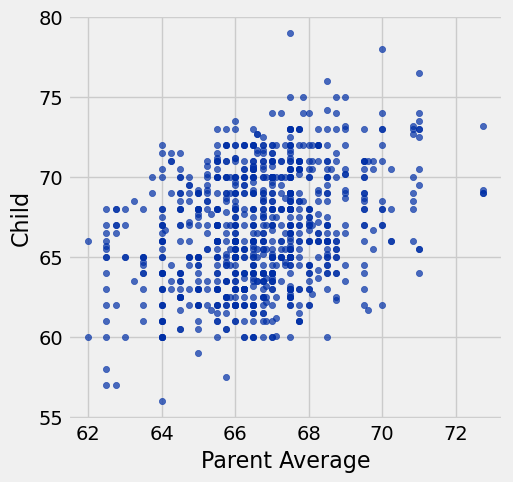

In [5]:
heights.scatter('Parent Average', 'Child')

How would you classify this scatter?

What questions or observations could be made about these variables?

What are some things a Data Scientist could predict using this data?

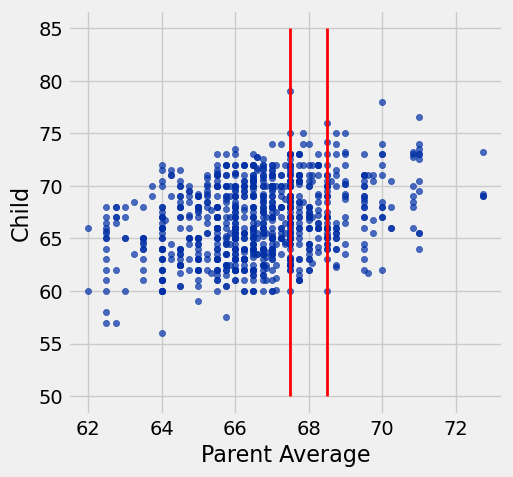

In [6]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2);

What do the red vertical lines represent and what are they helping with?

In [7]:
nearby = heights.where('Parent Average', are.between(67.5, 68.5))
nearby_mean = np.average(nearby.column('Child'))
nearby_mean

67.620000000000005

What does the nearby mean value represent?

What could this help predict?


The code below will plot the nearby mean on our scatterplot.

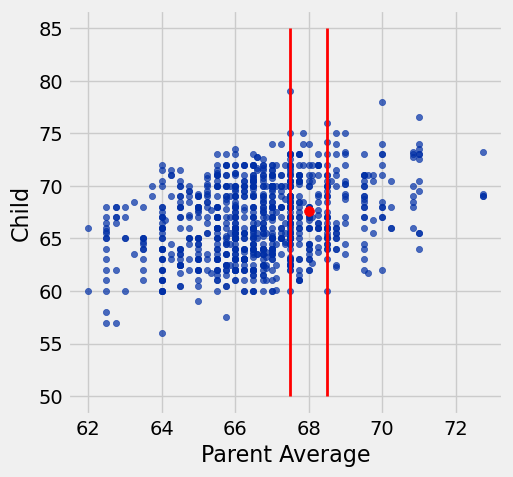

In [8]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, nearby_mean, color='red', s=50);

Below is a new function defined to do what?


In [9]:
def predict(h):
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    return np.average(nearby.column('Child'))

Use the new function to predit ...

In [10]:
# Use the function to make a predictions for parents whose average height is 68"
predict(68)

67.620000000000005

In [11]:
# Use the function to make a predictions for parents whose average height is 70"
predict(70)

68.561904761904756

In [12]:
# Use the function to make a predictions for parents whose average height is 73"
predict(73)

70.099999999999994

What does the code below do?

In [13]:
predicted_heights = heights.apply(predict, 'Parent Average')

In [14]:
heights = heights.with_column('Prediction', predicted_heights)
heights

Parent Average,Child,Sex,Prediction
72.75,73.2,male,70.1
72.75,69.2,female,70.1
72.75,69,female,70.1
72.75,69,female,70.1
71,73.5,male,70.4158
71,72.5,male,70.4158
71,65.5,female,70.4158
71,65.5,female,70.4158
69.5,71,male,68.5025
69.5,68,female,68.5025


Create a new scatter that shows all the predicted heights.

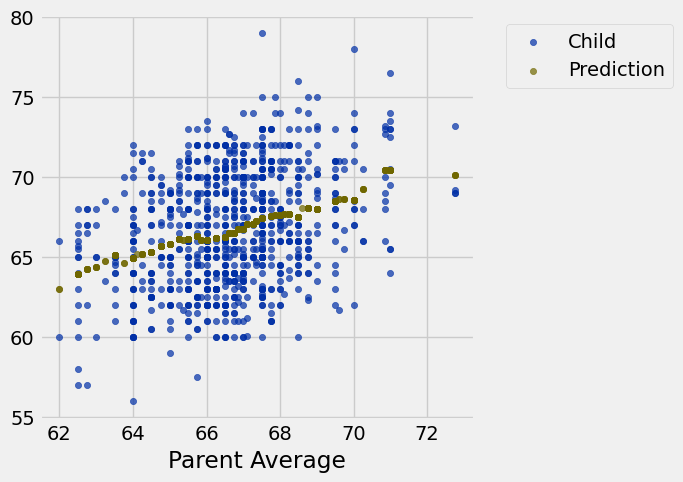

In [15]:
heights.select('Parent Average', 'Child', 'Prediction').scatter('Parent Average')

## Prediction Accuracy ##

Prediction is rarely perfect. We may over or under estimate the correct value. 
Notice in the scatter above, there are data points above and below every prediction value. This is because this value is an average. 


In [16]:
# Define a new function to compute the difference between two values. 
def difference(x, y):
    return x - y

What will the code below produce?

In [17]:
pred_errs = heights.apply(difference, 'Prediction', 'Child')
heights = heights.with_column('errors',pred_errs)
heights

Parent Average,Child,Sex,Prediction,errors
72.75,73.2,male,70.1,-3.1
72.75,69.2,female,70.1,0.9
72.75,69,female,70.1,1.1
72.75,69,female,70.1,1.1
71,73.5,male,70.4158,-3.08421
71,72.5,male,70.4158,-2.08421
71,65.5,female,70.4158,4.91579
71,65.5,female,70.4158,4.91579
69.5,71,male,68.5025,-2.4975
69.5,68,female,68.5025,0.5025


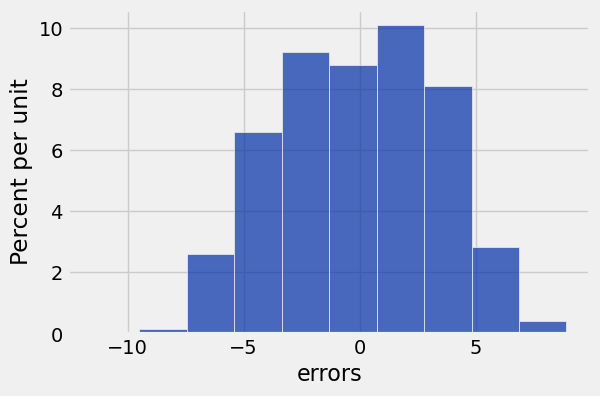

In [18]:
heights.hist('errors')

The histogram above shows the prediction errors. 
What is the shape? 

What are the values centered around? Why?

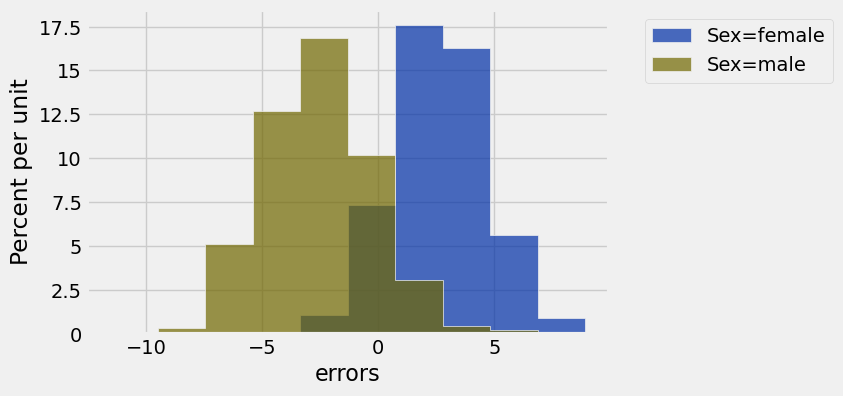

In [19]:
heights.hist('errors', group='Sex')

What does the histogram above show?

How would you classify these histograms?

What did disaggregating these values reveal?

# Discussion Questions

1. How could we take sex into account when making predictions?
2. Do we make smaller errors on average when we do this?

Let's start by creating a new function. How is this function different than the original prediction function?


In [20]:
#Original Function:
#def predict(h):
#    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
#    return np.average(nearby.column('Child'))

def predict_smarter(h, s):
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    nearby_same_sex = nearby.where('Sex', s)
    return np.average(nearby_same_sex.column('Child'))

In [21]:
# Use the new function to predict the average female's height born to parents with an average height of 68".
predict_smarter(68, 'female')

64.983516483516482

In [22]:
# Use the new function to predict the average male's height born to parents with an average height of 68"
predict_smarter(68, 'male')

70.172340425531914

In [23]:
smarter_predicted_heights = heights.apply(predict_smarter, 'Parent Average', 'Sex')
heights = heights.with_column('Smarter Prediction', smarter_predicted_heights)

In [24]:
smarter_pred_errs = heights.apply(difference, 'Child', 'Smarter Prediction')
heights = heights.with_column('Smarter Errors', smarter_pred_errs)
heights

Parent Average,Child,Sex,Prediction,errors,Smarter Prediction,Smarter Errors
72.75,73.2,male,70.1,-3.1,73.2,0
72.75,69.2,female,70.1,0.9,69.0667,0.133333
72.75,69,female,70.1,1.1,69.0667,-0.0666667
72.75,69,female,70.1,1.1,69.0667,-0.0666667
71,73.5,male,70.4158,-3.08421,73.4889,0.0111111
71,72.5,male,70.4158,-2.08421,73.4889,-0.988889
71,65.5,female,70.4158,4.91579,67.65,-2.15
71,65.5,female,70.4158,4.91579,67.65,-2.15
69.5,71,male,68.5025,-2.4975,70.7955,0.204545
69.5,68,female,68.5025,0.5025,65.7,2.3


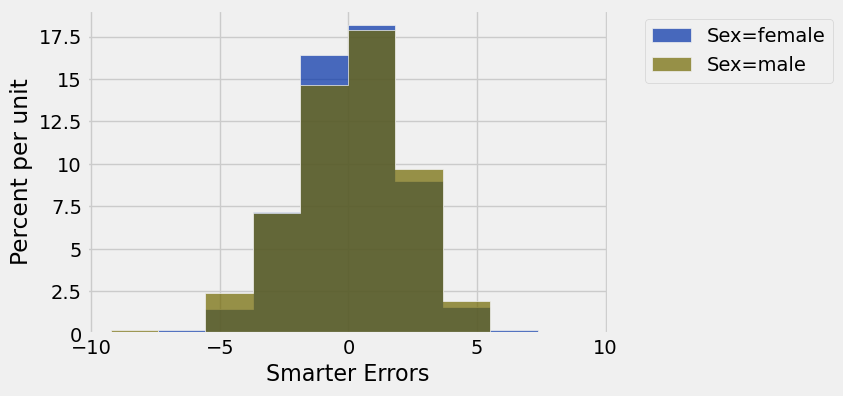

In [25]:
heights.hist('Smarter Errors', group='Sex')

Did the function change improve the prediction results? How do you know?


## Grouping by One Column ##

In [26]:
cones = Table.read_table('cones.csv').drop('Color')
cones

Flavor,Price
strawberry,3.55
chocolate,4.75
chocolate,5.25
strawberry,5.25
chocolate,5.25
bubblegum,4.75


In [27]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


In [28]:
cones.group('Flavor', np.average)

Flavor,Price average
bubblegum,4.75
chocolate,5.08333
strawberry,4.4


In [29]:
cones.group('Flavor', np.min)

Flavor,Price min
bubblegum,4.75
chocolate,4.75
strawberry,3.55


## Grouping By One Column: Welcome Survey ##

In [30]:
survey = Table.read_table('welcome_survey_sp22.csv')
survey.show(3)

Year,Extroversion,Number of textees,Hours of sleep,Handedness,Pant leg,Sleep position,Pets,Piercings
Second,5,5,8,Left-handed,Left leg in first,On your left side,Ants,0
Fourth,2,3,7,Right-handed,Left leg in first,On your left side,"Beetles, Centipedes, Scorpions",0
First,3,4,8,Right-handed,Right leg in first,On your back,Bird,0


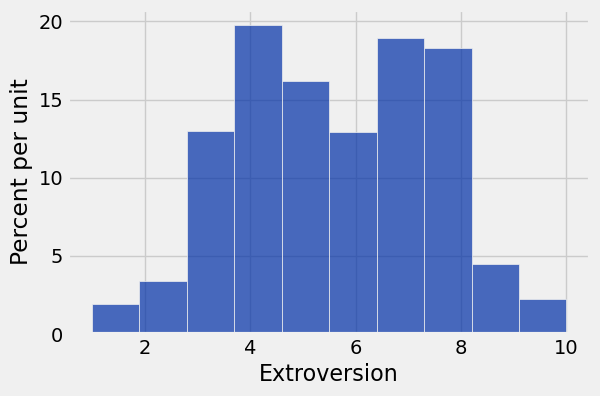

In [31]:
survey.hist('Extroversion')

In [32]:
by_extra = survey.group('Extroversion', np.average)
by_extra

Extroversion,Year average,Number of textees average,Hours of sleep average,Handedness average,Pant leg average,Sleep position average,Pets average,Piercings average
1,,2.08696,7.32609,,,,,0.478261
2,,3.21951,7.30488,,,,,0.95122
3,,4.71338,7.17516,,,,,1.57962
4,,4.96653,7.25941,,,,,1.7113
5,,5.39796,7.06888,,,,,1.45408
6,,5.8141,7.125,,,,,1.83974
7,,8.15721,7.04367,,,,,2.06987
8,,7.95475,7.07692,,,,,2
9,,10.7778,7.15741,,,,,2.88889
10,,13.037,7.16667,,,,,1.92593


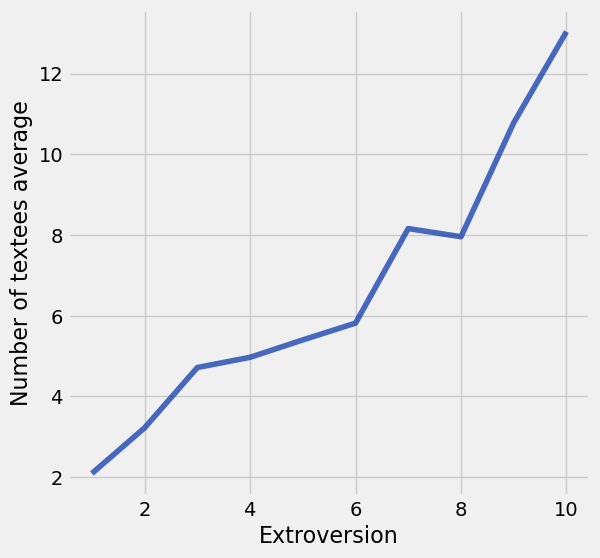

In [33]:
by_extra.plot('Extroversion', 'Number of textees average')

In [34]:
survey.group("Year")

Year,count
Fifth or above,18
First,577
First year In Master's Degree,1
Fourth,96
"I dont understand this question, I'm a first year but se ...",1
Junior Transfer,1
Not an undergrad,3
Second,419
Third,227


In [35]:
(survey
 .select("Year", "Hours of sleep")
 .group(0, np.average)
 .take(1, 7, 8, 3))

Year,Hours of sleep average
First,7.19757
Second,7.1778
Third,6.96696
Fourth,6.92188


## Lists

In [36]:
[1, 5, 'hello', 5.0]

[1, 5, 'hello', 5.0]

In [37]:
[1, 5, 'hello', 5.0, make_array(1,2,3)]

[1, 5, 'hello', 5.0, array([1, 2, 3])]

## Grouping by Two Columns ##

![Do right-handed people tend to sleep on their left side and left-handed people sleep on their right?](handed.png)

In [38]:
survey.group(['Handedness', 'Sleep position']).show()

Handedness,Sleep position,count
Both,On your back,2
Both,On your left side,1
Both,On your right side,3
Both,On your stomach,3
Left-handed,On your back,15
Left-handed,On your left side,30
Left-handed,On your right side,31
Left-handed,On your stomach,17
Right-handed,On your back,299
Right-handed,On your left side,315
